In [24]:
import numpy as np
import pandas as pd
from sklearn.decomposition import FastICA
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

import numpy as np
import pandas as pd


In [2]:
inDat=pd.read_csv("Giant_FC_matrix_genes_by_contextPerturbation_FDR0.01_zeroed.csv", index_col=0)

In [3]:
SelectedPerturbations = pd.read_csv("SignificantPerturbations.csv")
SelectedPerturbations=list(SelectedPerturbations.perturbation.unique())

In [4]:
perts=[str(x).split("__", 1)[1] for x in inDat.columns]
inDat=inDat.loc[:,[x in SelectedPerturbations for x in perts]]

In [5]:
sgnConds=pd.DataFrame(np.sum(inDat != 0, axis=1))
sgnConds = sgnConds.drop(["bfp", "dCas9", "gfp"])
sgnConds.columns=["NumberOfCods"]

In [6]:
sgnConds = sgnConds.sort_values(by="NumberOfCods")
sgnConds=sgnConds.loc[sgnConds.NumberOfCods > 1000,]

In [7]:
inDat=inDat.loc[sgnConds.index,:]

In [10]:
inDat=np.transpose(inDat)

In [25]:
def _fit_gene_programs_ica(
    X_train_nxg: np.ndarray,
    n_components: int,
    scale_genes: bool,
    random_state: int,
    max_iter: int,
    tol: float,
    algorithm: str,
    fun: str,
    whiten,
):
    
    X_train_s = np.asarray(X_train_nxg, dtype=np.float32)

    ica = FastICA(
        n_components=n_components,
        random_state=random_state,
        max_iter=max_iter,
        tol=tol,
        algorithm=algorithm,
        fun=fun,
        whiten=whiten,
    )

    # Fit ICA on train (in processed space)
    A_train = ica.fit_transform(X_train_s)   # (n_train, k)
    mixing = ica.mixing_                    # (n_genes, k) in processed (scaled) feature space

    # Convert programs back to the centered-but-unscaled gene space if we scaled
    if scale_genes:
        # X_scaled = X_centered / std  => mixing_centered = mixing_scaled * std
        mixing_centered = mixing * scaler.scale_[:, None]  # (n_genes, k)
    else:
        mixing_centered = mixing

    # Return gene programs as (k, n_genes)
    S_prog_kxg = mixing_centered.T  # (k, n_genes)

    return S_prog_kxg.astype(np.float32), ica


def _predict_rows_from_gene_programs_ols(
    X_test_nxg: np.ndarray,
    S_prog_kxg: np.ndarray,
):
    X_test_nxg = np.asarray(X_test_nxg, dtype=np.float32)
    S_prog_kxg = np.asarray(S_prog_kxg, dtype=np.float32)

    # Solve for A_test using library OLS:
    # X_test^T (g, n_test) ≈ S^T (g, k) @ A_test^T (k, n_test)
    reg = LinearRegression(fit_intercept=False)
    reg.fit(S_prog_kxg.T, X_test_nxg.T)     # coef_: (n_test, k)

    A_test_nxk = reg.coef_                  # (n_test, k)
    X_hat_T = reg.predict(S_prog_kxg.T)     # (g, n_test)
    X_hat_nxg = X_hat_T.T                   # (n_test, g)

    return X_hat_nxg.astype(np.float32), A_test_nxk.astype(np.float32)


def gene_program_ica_row_cv(
    X: pd.DataFrame | np.ndarray,   # rows=samples (pert×ctx), cols=genes
    n_components_list,
    test_size: float = 0.2,
    n_splits: int = 5,
    random_state: int = 0,
    scale_genes: bool = False,
    max_iter: int = 2000,
    tol: float = 1e-4,
    algorithm: str = "parallel",
    fun: str = "logcosh",
    whiten="unit-variance",
):
    
    if isinstance(X, pd.DataFrame):
        X_nxg = X.to_numpy(dtype=np.float32)
    else:
        X_nxg = np.asarray(X, dtype=np.float32)

    # ---------- GLOBAL CENTERING (before CV) ----------
    X_nxg = X_nxg - X_nxg.mean(axis=0, keepdims=True)

    n_samples, n_genes = X_nxg.shape
    n_components_list = list(n_components_list)

    splitter = ShuffleSplit(
        n_splits=n_splits,
        test_size=test_size,
        random_state=random_state,
    )

    records = []

    for split_id, (train_idx, test_idx) in enumerate(splitter.split(np.arange(n_samples))):
        X_train = X_nxg[train_idx, :]   # centered (n_train, g)
        X_test  = X_nxg[test_idx, :]    # centered (n_test, g)

        # Denominator for global R² in centered space
        ss_total = float(np.sum(X_test ** 2))
        if ss_total <= 0:
            ss_total = np.nan

        for k in n_components_list:
            print(k)
            # feasible k: <= min(n_train-1, n_genes)
            k_eff = int(min(k, X_train.shape[0] - 1, X_train.shape[1]))
           
            # Fit ICA -> gene programs in centered (unscaled) gene units
            S_prog_kxg, ica = _fit_gene_programs_ica(
                X_train_nxg=X_train,
                n_components=k_eff,
                scale_genes=scale_genes,
                random_state=random_state + split_id,
                max_iter=max_iter,
                tol=tol,
                algorithm=algorithm,
                fun=fun,
                whiten=whiten,
            )

            X_test_proc = X_test
            S_prog_proc = S_prog_kxg

            # Reconstruct test in processed space
            X_hat_proc, A_test = _predict_rows_from_gene_programs_ols(
                X_test_nxg=X_test_proc,
                S_prog_kxg=S_prog_proc,
            )

            ss_resid = float(np.sum((X_test_proc - X_hat_proc) ** 2))
            R2 = 1.0 - (ss_resid / ss_total)

            records.append({"split": split_id, "n_components": k, "k_eff": k_eff, "R2_test": float(R2)})

    details_df = pd.DataFrame.from_records(records)

    summary_df = (
        details_df.groupby("n_components")["R2_test"]
        .agg(mean_R2_test="mean", sd_R2_test="std", n="count")
        .reset_index()
    )

    raw = details_df.groupby("n_components")["R2_test"].apply(list).reset_index(name="all_R2_test")
    summary_df = summary_df.merge(raw, on="n_components", how="left")

    return summary_df, details_df


In [26]:
n_components_list = [5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110,120,130]

summary_df, details_df = gene_program_ica_row_cv(
    X=inDat,
    n_components_list=n_components_list,
    test_size=0.2,
    n_splits=5,
    random_state=0,
    scale_genes=False)


5
10
15
20
30
40
50
60
70
80
90
100
110
120
130
5
10
15
20
30
40
50
60
70
80
90
100
110
120
130
5
10
15
20
30
40
50
60
70
80
90
100
110
120
130
5
10
15
20
30
40
50
60
70
80
90
100
110
120
130
5
10
15
20
30
40
50
60
70
80
90
100
110
120
130


In [28]:
details_df

,split,n_components,k_eff,R2_test
0,0,5,5,0.484337
1,0,10,10,0.558757
2,0,15,15,0.637109
3,0,20,20,0.720958
4,0,30,30,0.802958
...,...,...,...,...
70,4,90,90,0.972386
71,4,100,100,0.974368
72,4,110,110,0.976217
73,4,120,120,0.977805


In [29]:
summary_df.to_csv("ICA_expVar.csv")

In [30]:
long_df = summary_df.explode("all_R2_test").copy()
long_df["all_R2_test"] = long_df["all_R2_test"].astype(float)



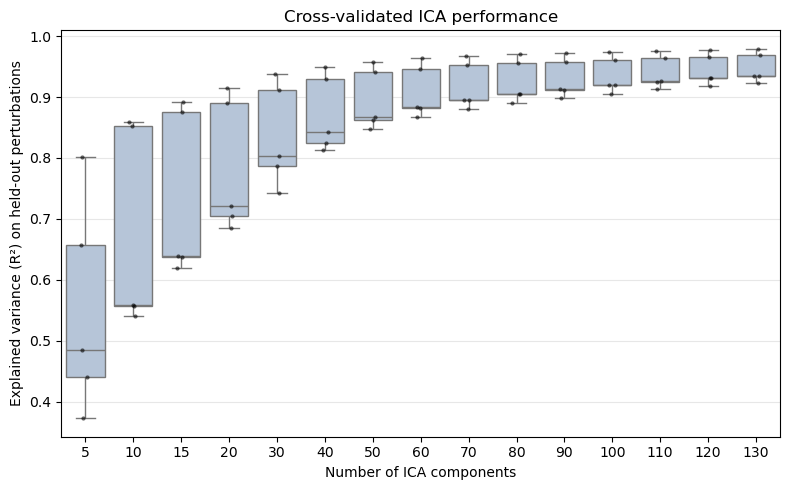

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=long_df,
    x="n_components",
    y="all_R2_test",
    color="lightsteelblue",
)


sns.stripplot(
    data=long_df,
    x="n_components",
    y="all_R2_test",
    color="black",
    size=3,
    alpha=0.6,
    jitter=True,
)

plt.xlabel("Number of ICA components")
plt.ylabel("Explained variance (R²) on held-out perturbations")
plt.title("Cross-validated ICA performance")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [32]:
summary_df

,n_components,mean_R2_test,sd_R2_test,n,all_R2_test
0,5,0.551398,0.175131,5,"[0.48433673368271146, 0.3727464311130223, 0.44..."
1,10,0.673547,0.166435,5,"[0.5587572444995597, 0.5571626869689967, 0.540..."
2,15,0.732509,0.138481,5,"[0.6371088489303008, 0.6385114993722514, 0.619..."
3,20,0.783261,0.110612,5,"[0.7209581016807962, 0.7045092014940795, 0.684..."
4,30,0.836136,0.083941,5,"[0.8029581647550909, 0.7860469521956094, 0.742..."
5,40,0.871970,0.063525,5,"[0.8432548628550918, 0.823848757775369, 0.8125..."
6,50,0.895179,0.050167,5,"[0.867119016317839, 0.8620207937337364, 0.8482..."
7,60,0.908636,0.043200,5,"[0.8830396426660325, 0.8825247551996305, 0.867..."
8,70,0.918151,0.038819,5,"[0.8958381897394324, 0.8950391607753977, 0.880..."
9,80,0.925077,0.035288,5,"[0.9049054833268372, 0.904570479144557, 0.8903..."


In [105]:
import numpy as np
import pandas as pd
from sklearn.decomposition import FastICA
from sklearn.preprocessing import StandardScaler


def fit_ica_full_and_extract_modules(
    X: pd.DataFrame,                 # rows = {context}__{perturbation} (samples), cols = genes
    n_components: int,
    scale_genes: bool = False,
    random_state: int = 0,
    max_iter: int = 3000,
    tol: float = 1e-4,
    algorithm: str = "parallel",
    fun: str = "logcosh",
    whiten="unit-variance",
    gene_z: float = 3.0,             # outlier threshold for gene weights
    pert_z: float = 3.0,             # outlier threshold for perturbation activities
):
    """
    Fit ICA on the full matrix (globally centered), then:
      1) extract gene modules (outlier gene weights per component)
      2) extract perturbation/context activations (outlier sample activities per component)
      3) compute per-component "explained variance" proxies in ICA fit space:
         - marginal_R2_k: R² using only component k
         - rank1_energy_frac_k: ||a_k s_k^T||^2 / ||X||^2  (not additive)

    Returns
    -------
    S_prog : pd.DataFrame (K x G)
        Gene program weights (rows=components, cols=genes) in centered (unscaled) units
    A_act : pd.DataFrame (N x K)
        Program activities (rows=samples, cols=components) in ICA space (scaled if scale_genes=True)
    gene_modules : dict[str, pd.DataFrame]
        component -> genes with |z| >= gene_z (gene, weight, z, sign)
    pert_outliers : dict[str, pd.DataFrame]
        component -> samples with |z| >= pert_z (sample, context, perturbation, activity, z, sign)
    comp_stats : pd.DataFrame
        Per-component summary with marginal_R2 and rank1_energy_frac
    """
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X must be a pandas DataFrame with index=samples and columns=genes.")

    sample_idx = pd.Index(X.index.astype(str))
    gene_names = pd.Index(X.columns.astype(str))

    X_nxg = X.to_numpy(dtype=np.float32)

    # ---------- global centering over samples (per gene / column-wise) ----------
    X_center = X_nxg - X_nxg.mean(axis=0, keepdims=True)

    # ---------- optional gene scaling ----------
    
    X_proc = X_center

    # ---------- ICA ----------
    ica = FastICA(
        n_components=n_components,
        random_state=random_state,
        max_iter=max_iter,
        tol=tol,
        algorithm=algorithm,
        whiten=whiten,
    )

    # A_act: (N x K) independent component activations per sample
    A_act_np = ica.fit_transform(X_proc)          # (N, K)

    # mixing_: (G x K) in processed space
    mixing_proc = ica.mixing_                     # (G, K)

    # Programs in centered, unscaled gene units (K x G) for interpretability
    mixing_centered = mixing_proc

    S_prog_np = mixing_centered.T                 # (K, G)

    comp_names = [f"IC{i+1}" for i in range(n_components)]
    S_prog = pd.DataFrame(S_prog_np, index=comp_names, columns=gene_names)
    A_act  = pd.DataFrame(A_act_np, index=sample_idx, columns=comp_names)

    # ---------- robust parsing of "{context}__{perturbation}" ----------
    meta = sample_idx.to_series(index=sample_idx).astype(str).str.split("__", n=1, expand=True)
    if meta.shape[1] == 1:
        meta[1] = "NA"
    meta = meta.iloc[:, :2]
    meta.columns = ["context", "perturbation"]
    meta.index = sample_idx

    # ---------- extract gene modules: outlier genes per component ----------
    gene_modules = {}
    for ic in comp_names:
        w = S_prog.loc[ic].to_numpy(dtype=float)
        z = (w - w.mean()) / (w.std(ddof=0) + 1e-12)
        keep = np.abs(z) >= gene_z

        df = pd.DataFrame({
            "gene": gene_names[keep].to_numpy(),
            "weight": w[keep],
            "z": z[keep],
            "sign": np.where(w[keep] >= 0, "pos", "neg"),
        }).sort_values("z", key=np.abs, ascending=False)

        gene_modules[ic] = df.reset_index(drop=True)

    # ---------- extract perturbation/context outliers: outlier activities per component ----------
    pert_outliers = {}
    for ic in comp_names:
        a = A_act[ic].to_numpy(dtype=float)
        z = (a - a.mean()) / (a.std(ddof=0) + 1e-12)
        keep = np.abs(z) >= pert_z

        sel = sample_idx[keep]
        df = pd.DataFrame({
            "sample": sel.to_numpy(),
            "context": meta.loc[sel, "context"].to_numpy(),
            "perturbation": meta.loc[sel, "perturbation"].to_numpy(),
            "activity": a[keep],
            "z": z[keep],
            "sign": np.where(a[keep] >= 0, "pos", "neg"),
        }).sort_values("z", key=np.abs, ascending=False)

        pert_outliers[ic] = df.reset_index(drop=True)

    # ---------- per-component explained-variance proxies (in ICA fit space) ----------
    # Programs must be in the SAME space as X_proc for reconstruction.
    # If scale_genes=True, X_proc is scaled, so use S in processed space.
    if scale_genes:
        S_for_recon_kxg = mixing_proc.T.astype(np.float32)  # (K, G) in processed space
    else:
        S_for_recon_kxg = S_prog_np.astype(np.float32)      # (K, G) in centered space (same as X_proc)

    ss_total = float(np.sum(X_proc ** 2)) + 1e-12  # since centered
    comp_rows = []
    for k, ic in enumerate(comp_names):
        a_k = A_act_np[:, k]                        # (N,)
        s_k = S_for_recon_kxg[k, :]                 # (G,)

        Xk = a_k[:, None] * s_k[None, :]            # (N, G) rank-1 reconstruction for component k

        # "Energy" fraction (not additive across k because ICA components not orthogonal)
        rank1_energy_frac = float(np.sum(Xk ** 2) / ss_total)

        # Marginal R²: reconstruction using only this component
        ss_resid = float(np.sum((X_proc - Xk) ** 2))
        marginal_R2 = 1.0 - (ss_resid / ss_total)

        comp_rows.append({
            "component": ic,
            "rank1_energy_frac": rank1_energy_frac,
            "marginal_R2": marginal_R2,
        })

    comp_stats = pd.DataFrame(comp_rows).sort_values("marginal_R2", ascending=False).reset_index(drop=True)

    return S_prog, A_act, gene_modules, pert_outliers, comp_stats


In [114]:
S_prog, A_act, gene_modules, pert_outliers, comp_stats = fit_ica_full_and_extract_modules(
   inDat,
   n_components=60,
   scale_genes=False,
   gene_z=1.0,
   pert_z=1.0)

In [115]:
comp_stats

,component,rank1_energy_frac,marginal_R2
0,IC58,0.369900,0.369907
1,IC27,0.100425,0.100421
2,IC36,0.062026,0.062025
3,IC4,0.032356,0.032357
4,IC26,0.030748,0.030742
5,IC10,0.022555,0.022551
6,IC25,0.022249,0.022247
7,IC39,0.019423,0.019422
8,IC22,0.018319,0.018315
9,IC35,0.014819,0.014820


In [74]:
def plot_ica_program_clustermap(
    X_df: pd.DataFrame,                 # rows = samples ({context}__{pert}), cols = genes
    gene_modules: dict,                 # from fit_ica_full_and_extract_modules
    pert_outliers: dict,                # from fit_ica_full_and_extract_modules
    component: str,                     # e.g. "IC1"
    top_genes: int | None = 200,        # None = all outlier genes
    top_samples: int | None = 200,      # None = all outlier samples
    use_abs_z: bool = True,             # rank outliers by |z|
    center_genes: bool = False,         # optional: center each gene across selected samples for visualization
    figsize=(10, 10),
    cmap="vlag",
    zscore_rows: bool = False,          # seaborn clustermap option
    metric="correlation",
    method="average",
    savepath: str | None = None,
    show=True,
):
    """
    Clustered heatmap for one ICA component:
      rows = program genes
      cols = outlier samples (perturbation-contexts) that affect the program

    Notes
    -----
    - X_df is assumed to contain fold-changes (can be centered already; not required for visualization).
    - If you want to display only positive/negative sets separately, filter gene_modules[component]
      by 'sign' or filter pert_outliers[component] by 'sign' before calling.
    """
 
    # --- select genes ---
    gm = gene_modules[component].copy()
    
    if use_abs_z and "z" in gm.columns:
        gm = gm.sort_values("z", key=np.abs, ascending=False)
    elif "z" in gm.columns:
        gm = gm.sort_values("z", ascending=False)

    genes = gm["gene"].astype(str).tolist()
   
    # --- select samples (perturbation-contexts) ---
    po = pert_outliers[component].copy()
    
    if use_abs_z and "z" in po.columns:
        po = po.sort_values("z", key=np.abs, ascending=False)
    elif "z" in po.columns:
        po = po.sort_values("z", ascending=False)

    samples = po["sample"].astype(str).tolist()
   
    # --- subset matrix and orient: rows=genes, cols=samples ---
    # X_df: (samples x genes) -> want (genes x samples)
    missing_genes = [g for g in genes if g not in X_df.columns]
    missing_samp  = [s for s in samples if s not in X_df.index]
    if missing_genes:
        print(f"[warn] {component}: {len(missing_genes)} genes missing from X_df.columns (dropping).")
    if missing_samp:
        print(f"[warn] {component}: {len(missing_samp)} samples missing from X_df.index (dropping).")

    genes = [g for g in genes if g in X_df.columns]
    samples = [s for s in samples if s in X_df.index]

    if len(genes) < 2 or len(samples) < 2:
        raise ValueError(
            f"{component}: need at least 2 genes and 2 samples after filtering "
            f"(got {len(genes)} genes, {len(samples)} samples)."
        )

    mat = X_df.loc[samples, genes].T  # (genes x samples)

    # # Optional: make patterns easier to see
    # if center_genes:
    #     mat = mat.sub(mat.mean(axis=1), axis=0)

    mat[mat> 0.3] = 0.3
    mat[mat < -0.3] = -0.3
    

    # --- plot clustermap ---
    g = sns.clustermap(
        mat,
        figsize=figsize,
        cmap=cmap,
        metric=metric,
        method=method,
        z_score=0 if zscore_rows else None,  # z-score rows (genes) if requested
        xticklabels=True,
        yticklabels=False,
    )
    g.fig.suptitle(f"{component}: program genes × outlier perturbation-contexts", y=1.02)

    if savepath is not None:
        g.fig.savefig(savepath, dpi=200, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(g.fig)

    return g


In [130]:
gm = gene_modules["IC4"].copy()
genes = gm["gene"].astype(str).tolist()
genes

['SSTR1',
 'MCTP1',
 'LEFTY1',
 'FAM20A',
 'MGAT4C',
 'PYDC1',
 'TRBC2',
 'GASK1B',
 'VGF',
 'SPP1',
 'TBX5',
 'TRIML2',
 'PLAAT4',
 'NPY1R',
 'GDF3',
 'GPR87',
 'SERPINE1',
 'CFAP95',
 'NMNAT2',
 'PTPRN',
 'SOX3',
 'TNNT2',
 'NANOG',
 'F5',
 'ANXA3',
 'ITGA3',
 'TTYH1',
 'HPGD',
 'NMRK2',
 'HTR7',
 'ACTA1',
 'ELAVL3',
 'MAFB',
 'RASGRF2',
 'TFAP2C',
 'PPP2R2B',
 'COL17A1',
 'CAV1',
 'PLAAT3',
 'GNA14',
 'B3GALT5',
 'PPP2R2C',
 'SLC16A12',
 'WSCD1',
 'EDNRB',
 'ANXA1',
 'MYOF',
 'CHST9',
 'KRT7',
 'HSD11B2',
 'VEPH1',
 'CLDN4',
 'PPP1R1A',
 'ALDH1A3',
 'MMP24',
 'CAV2',
 'PRDM14',
 'IL6',
 'TAP1',
 'ADAMTS16',
 'RAB17',
 'GRPR',
 'ABCA3',
 'GPR160',
 'OVOL2',
 'COL12A1',
 'B3GNT7',
 'MASP1',
 'NFE2L3',
 'CARMIL2',
 'HRK',
 'NEFL']

In [131]:
po = pert_outliers["IC4"].copy()
samples = po["sample"].astype(str).tolist()
samples

['CHIR__CTNNB1',
 'CHIR__PPP2R3C',
 'CHIR__FBLN1',
 'CHIR__BAZ1A',
 'CHIR__TSC22D2',
 'CHIR__MAL2',
 'CHIR__RNF8',
 'CHIR__SLC39A6',
 'PFI1__KDM1A',
 'CHIR__PHF3',
 'CHIR-98014__HDAC3',
 'PFI1__DHX36',
 'CHIR-98014__HEBP1',
 'CHIR__EPB41L1',
 'CHIR-98014__PHF3',
 'AZD4573__ZZZ3',
 'CHIR__ATP6V0B',
 'CHIR__MTA2',
 'CHIR__RFNG',
 'CHIR-98014__SLC39A6',
 'CHIR__TCF25',
 'CHIR__CTBP2',
 'CHIR__CBX2',
 'PP121__DHX36',
 'CHIR-98014__PPP2R3C',
 'CHIR-98014__TCEA2',
 'CHIR__WSB2',
 'LDN__SALL4',
 'PFI1__CHP1',
 'CHIR-98014__DHX36',
 'CHIR__OSTC',
 'Romidepsin__SBDS',
 'CHIR__AKR1A1',
 'CHIR__MRPS2',
 'CHIR__EPHB4',
 'CHIR-98014__TACC3',
 'LDN__DHX36',
 'AZD4573__BRPF1',
 'PP121__SLC39A6',
 'CHIR-98014__FNBP1L',
 'AZD4573__ELOF1',
 'CHIR__ASAP2',
 'CHIR-98014__MAL2',
 'PFI1__BTAF1',
 'CHIR-98014__SCCPDH',
 'CHIR__TAF4B',
 'LDN__COG2',
 'CHIR-98014__ZNF667',
 'CHIR-98014__SSB',
 'CHIR-98014__RPIA',
 'CHIR-98014__CHP1',
 'CHIR__TTYH3',
 'KYA__BAZ1A',
 'LDN__TOX4',
 'PFI1__REST',
 'Romidepsin__HEB

In [132]:
genes = [g for g in genes if g in inDat.columns]
samples = [s for s in samples if s in inDat.index]


In [133]:
mat = inDat.loc[samples, genes].T 

In [134]:
mat[mat> 0.5] = 0.5
mat[mat < -0.5] = -0.5


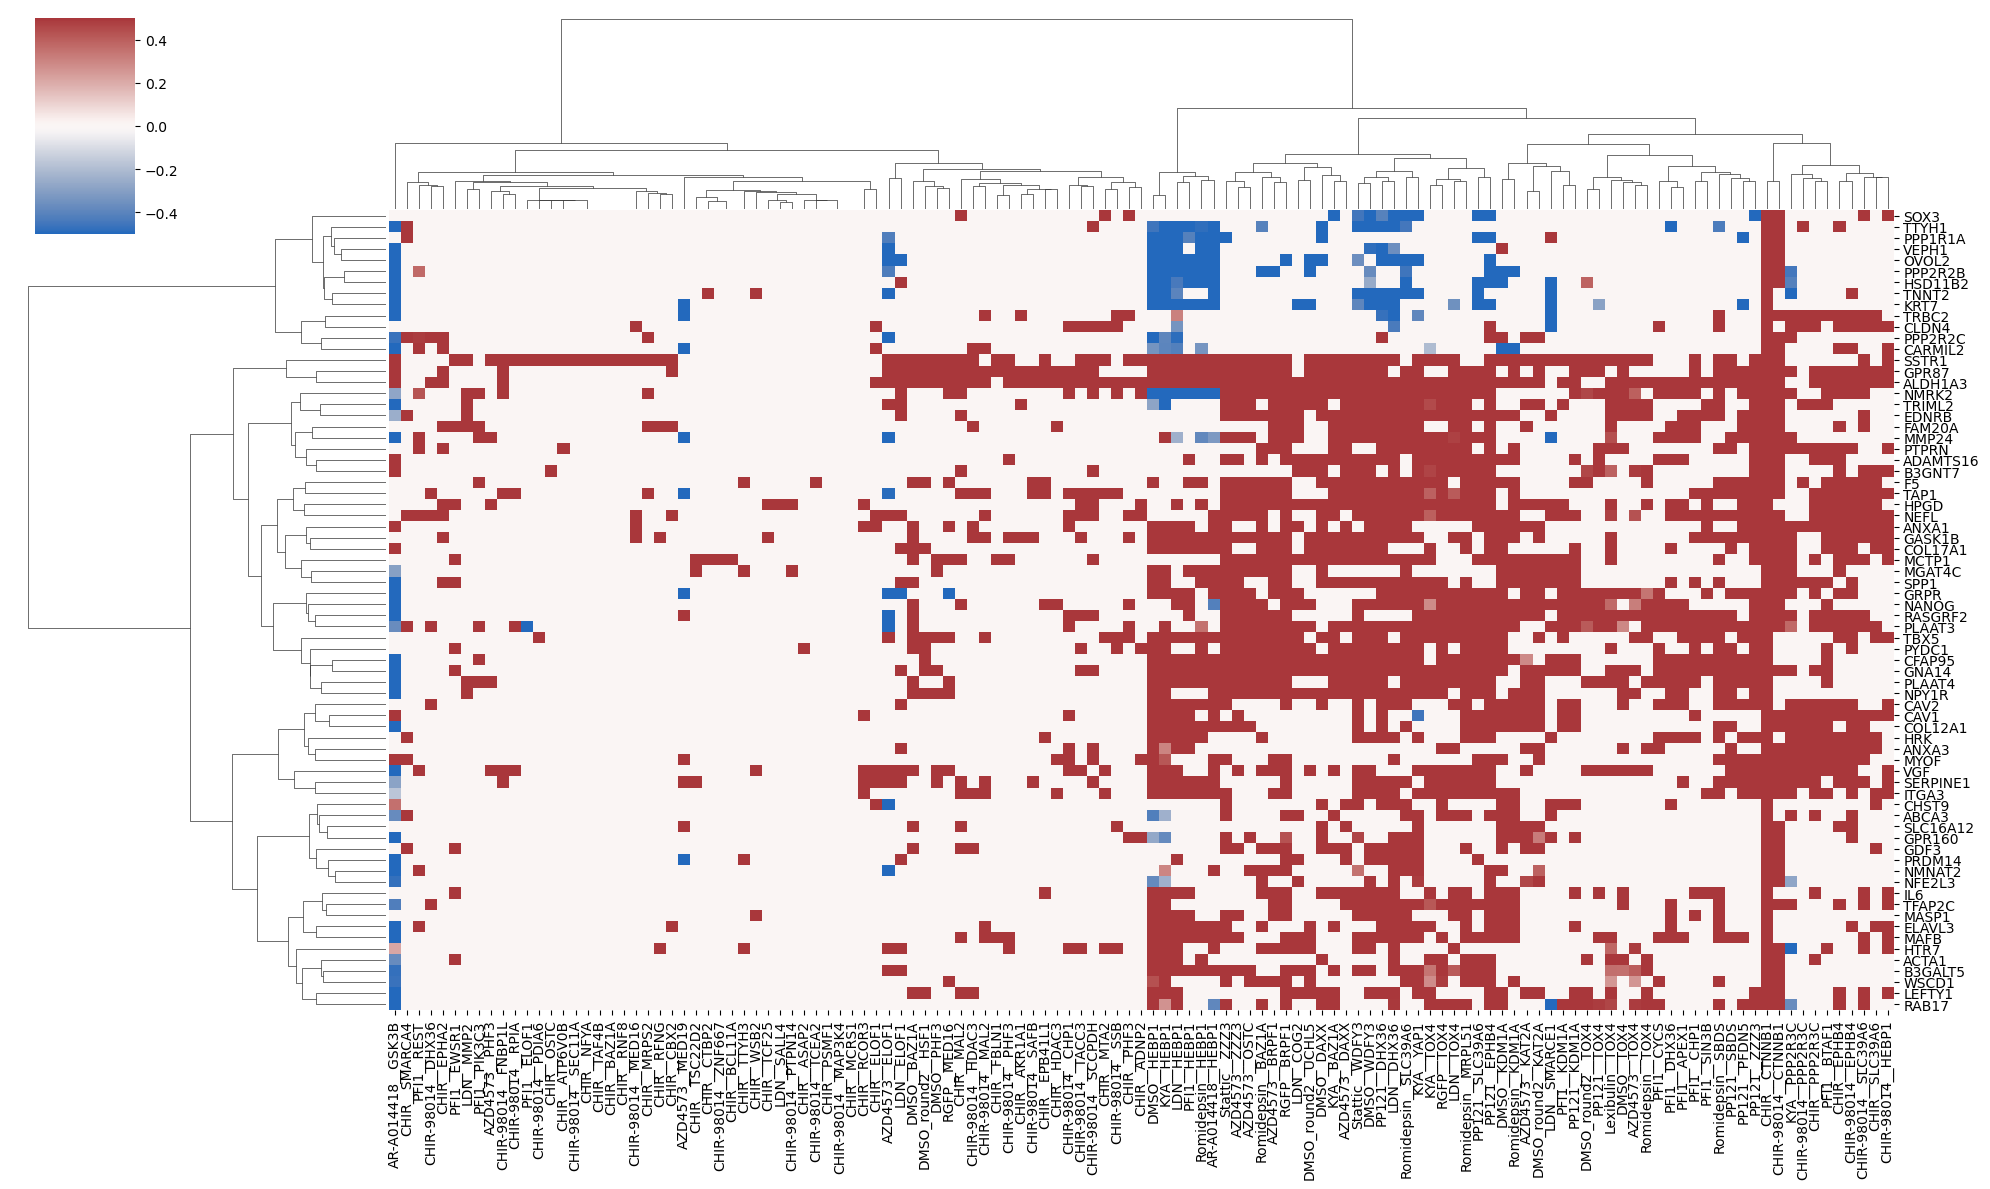

In [137]:
g = sns.clustermap(
    mat,
    figsize=(20,12),
    cmap="vlag",
    method="ward",
    xticklabels=True,
    yticklabels=True,
)


In [75]:
def plot_all_program_heatmaps(
    X_df,
    gene_modules,
    pert_outliers,
    components=None,
    out_dir=None,
    **kwargs,
):
    if components is None:
        components = list(gene_modules.keys())

    for comp in components:
        savepath = None
        if out_dir is not None:
            savepath = f"{out_dir}/{comp}_clustermap.png"

        try:
            plot_ica_program_clustermap(
                X_df=X_df,
                gene_modules=gene_modules,
                pert_outliers=pert_outliers,
                component=comp,
                savepath=savepath,
                **kwargs,
            )
        except Exception as e:
            print(f"[skip] {comp}: {e}")


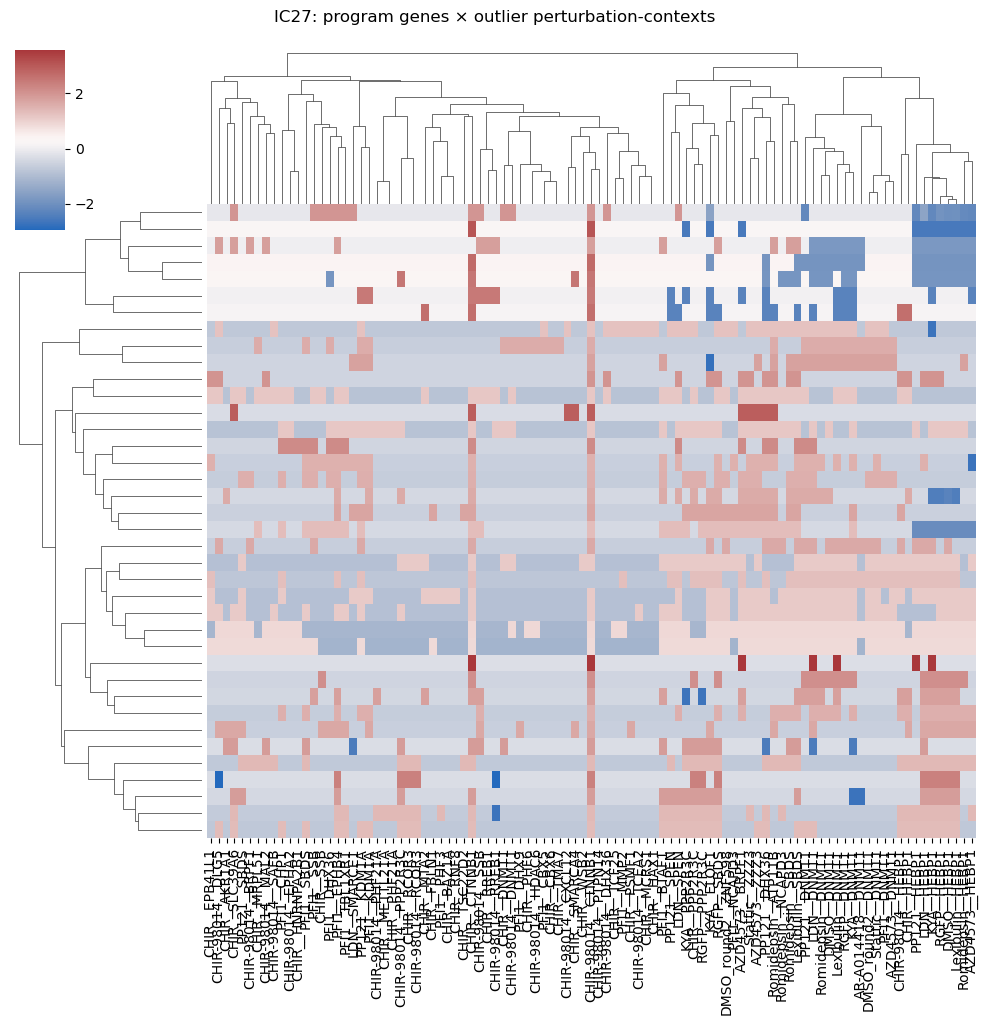

In [77]:
plot_ica_program_clustermap(
    X_df=inDat,
    gene_modules=gene_modules,
    pert_outliers=pert_outliers,
    component="IC27",
    zscore_rows=True,      # makes gene patterns clearer
    metric="correlation",
    method="average",
)

In [70]:
comp_stats

,component,rank1_energy_frac,marginal_R2
0,IC58,0.369900,0.369907
1,IC27,0.100425,0.100421
2,IC36,0.062026,0.062025
3,IC4,0.032356,0.032357
4,IC26,0.030748,0.030742
5,IC10,0.022555,0.022551
6,IC25,0.022249,0.022247
7,IC39,0.019423,0.019422
8,IC22,0.018319,0.018315
9,IC35,0.014819,0.014820


In [ ]:
# -------------------------
# Example usage
# -------------------------
# X_df: rows are "context__perturbation", columns are genes
# n_components_opt = 25
#

#
# # Gene module for IC1
# gene_modules["IC1"].head(30)
#
# # Perturbations/contexts that strongly activate IC1
# pert_outliers["IC1"].head(30)
#
# # Save outputs
# S_prog.to_csv("ICA_gene_programs_S_kxg.csv")
# A_act.to_csv("ICA_program_activities_A_nxk.csv")
#
# # Save per-component module members
# for ic, df in gene_modules.items():
#     df.to_csv(f"ICA_gene_module_{ic}.csv", index=False)
#
# for ic, df in pert_outliers.items():
#     df.to_csv(f"ICA_activity_outliers_{ic}.csv", index=False)
